## Regresion de Temperatura de Servicio Máxima

variables objetivo para regresion:
-Critica para selecci ́on de producto
-Depende de m ́ultiples factores



In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
df=pd.read_csv("/content/limpia2.csv")

In [ ]:
df.head()

,iddatosgrasas,codigograsa,aceite_base,espesante,grado_nlgi_consistencia,viscosidad_del_aceite_base_a_40degc_cst,penetracion_de_cono_a_25degc_0.1mm,punto_de_gota_degc,estabilidad_mecanica,punto_de_soldadura_cuatro_bolas_kgf,...,factor_de_velocidad,temperatura_de_servicio_degc_min,temperatura_de_servicio_degc_max,categoria,subtitulo,descripcion,beneficios,aplicaciones,color,textura
0,1,grasa_1,semi-sintetico,complejo sulfonato de calcio,2.0,680.0,279,304,1.07,500.0,...,200000.0,5,220,grasa,grasa de servicio pesado para alta resistencia...,el producto es grasa lubricante de servicio pe...,excelentes caracterã­sticas de resistencia al ...,debido a su composiciã³n ã³ptima de aceites de...,cafe,suave
1,2,grasa_2,mineral ht,complejo sulfonato de calcio,1.5,460.0,300,304,2.6,900.0,...,300000.0,-30,150,grasa,grasa para lubricaciã³n de equipo pesado.,el producto es una grasa lubricante de gran ad...,extremo soporte de carga.\r\n@alto contenido d...,lubricaciã³n centralizada de equipo pesado.\r\...,negro,adherente
2,3,grasa_3,mineral ht,complejo sulfonato de calcio,2.0,460.0,265 - 295,300,10,500.0,...,NaN,-10,150,grasa,grasa para lubricaciã³n de equipo pesado.,el producto es una grasa lubricante de gran ad...,extremo soporte de carga.\r\n@alto contenido d...,lubricaciã³n centralizada de equipo pesado.\r\...,negro,adherente
3,4,grasa_4,mineral ht,complejo sulfonato de calcio,2.0,220.0,266 - 295,300,5,500.0,...,NaN,-15,150,grasa,grasa lubricante para condiciones extremas.,el producto es una grasa lubricante elaborada ...,alta estabilidad tã©rmica y anti-oxidante.\r\n...,rodamientos expuestos a alta temperatura y car...,ambar,suave
4,5,grasa_5,mineral ht,complejo de aluminio - poliurea,1.5,680.0,295,260,6.5,620.0,...,NaN,-5,150,grasa,grasa lubricante para servicio pesado con alta...,el producto es un grasa lubricante con propied...,excelente soporte de carga extrema.\r\n@excele...,el producto es ideal para la lubricaciã³n de m...,negro,adherente


In [ ]:
print(df.columns)

Index(['iddatosgrasas', 'codigograsa', 'aceite_base', 'espesante',
       'grado_nlgi_consistencia', 'viscosidad_del_aceite_base_a_40degc_cst',
       'penetracion_de_cono_a_25degc_0.1mm', 'punto_de_gota_degc',
       'estabilidad_mecanica', 'punto_de_soldadura_cuatro_bolas_kgf',
       'desgaste_cuatro_bolas_mm', 'indice_de_carga-desgaste',
       'carga_timken_ok_lb', 'resistencia_al_lavado_por_agua_a_80degc',
       'corrosion_al_cobre', 'registro_nsf', 'factor_de_velocidad',
       'temperatura_de_servicio_degc_min', 'temperatura_de_servicio_degc_max',
       'categoria', 'subtitulo', 'descripcion', 'beneficios', 'aplicaciones',
       'color', 'textura'],
      dtype='object')


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

X = df[['punto_de_gota_degc', 'viscosidad_del_aceite_base_a_40degc_cst', 'espesante']].copy()
y = df['temperatura_de_servicio_degc_max'].copy()

# Convert 'punto_de_gota_degc' to numeric, coercing errors to NaN
X['punto_de_gota_degc'] = pd.to_numeric(X['punto_de_gota_degc'], errors='coerce')

# Drop rows with NaN values in the selected columns
X = X.dropna(subset=['punto_de_gota_degc', 'viscosidad_del_aceite_base_a_40degc_cst', 'espesante'])
y = y[X.index] # Ensure y corresponds to the filtered X

X = pd.get_dummies(X, columns=['espesante'], drop_first=True)


modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

print("\nCoeficientes del modelo:")
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f"  {nombre}: {coef:.4f}")

print("\nIntercepto:", round(modelo.intercept_, 4))
print("R² (bondad de ajuste):", round(r2_score(y, y_pred), 4))
print("RMSE (error promedio):", round(np.sqrt(mean_squared_error(y, y_pred)), 4))


Coeficientes del modelo:
  punto_de_gota_degc: 0.0366
  viscosidad_del_aceite_base_a_40degc_cst: -0.0057
  espesante_complejo de aluminio: 2.4881
  espesante_complejo de aluminio - poliurea: -5.7511
  espesante_complejo de litio: -44.0620
  espesante_complejo de poliurea: -46.1700
  espesante_complejo sulfonato de calcio: 12.4347
  espesante_silica: 82.6395

Intercepto: 150.1429
R² (bondad de ajuste): 0.6852
RMSE (error promedio): 17.8997


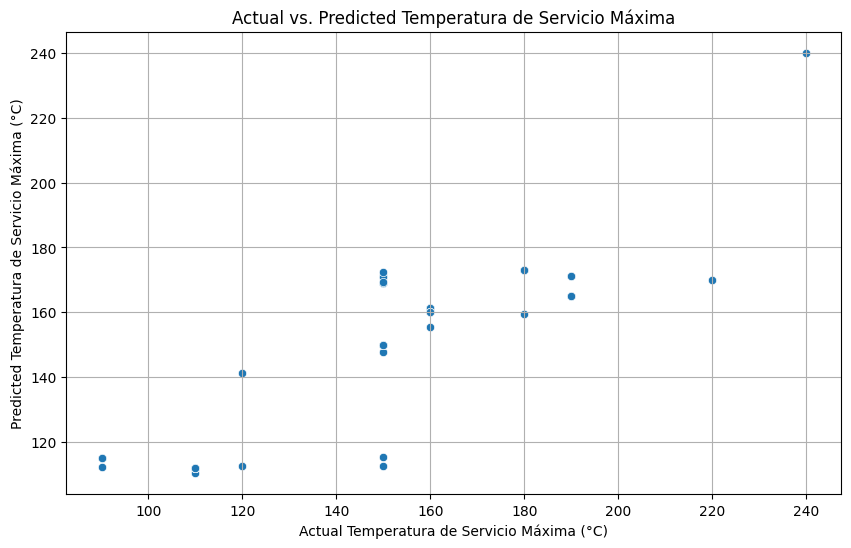

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred)
plt.xlabel("Actual Temperatura de Servicio Máxima (°C)")
plt.ylabel("Predicted Temperatura de Servicio Máxima (°C)")
plt.title("Actual vs. Predicted Temperatura de Servicio Máxima")
plt.grid(True)
plt.show()